# GPU Telemetry Exploration

Goal: dump everything the node exposes, see what pops.

**Structure**
1. Install & setup
2. GPU discovery + NVLink topology
3. Collect baseline metrics (60s, idle)
4. Visualize dashboard
5. DCGM deep dive: per-link NVLink data
6. [SHELVED] Stress test workloads

**Run on**: RunPod 16×A100 SXM node with root access.

---
## 1. Install & Setup

In [1]:
# !pip install nvidia-ml-py pandas matplotlib seaborn tqdm -q

In [2]:
# Verify GPU driver and nvidia-smi are present
!nvidia-smi --query-gpu=name,driver_version,memory.total --format=csv

name, driver_version, memory.total [MiB]
NVIDIA A100-SXM4-80GB, 570.172.08, 81920 MiB
NVIDIA A100-SXM4-80GB, 570.172.08, 81920 MiB
NVIDIA A100-SXM4-80GB, 570.172.08, 81920 MiB
NVIDIA A100-SXM4-80GB, 570.172.08, 81920 MiB
NVIDIA A100-SXM4-80GB, 570.172.08, 81920 MiB
NVIDIA A100-SXM4-80GB, 570.172.08, 81920 MiB
NVIDIA A100-SXM4-80GB, 570.172.08, 81920 MiB
NVIDIA A100-SXM4-80GB, 570.172.08, 81920 MiB


---
## 2. GPU Discovery + NVLink Topology

`pynvml` is a Python wrapper around NVML (NVIDIA Management Library) — the same thing `nvidia-smi` uses under the hood. We use it here to enumerate GPUs and inspect their NVLink connections.

In [3]:
import pynvml
import pandas as pd
import time

pynvml.nvmlInit()

driver_version = pynvml.nvmlSystemGetDriverVersion()
try:
    cuda_version = pynvml.nvmlSystemGetCudaDriverVersion()
except AttributeError:
    import subprocess
    out = subprocess.run(['nvidia-smi', '--query-gpu=driver_version', '--format=csv,noheader'],
                        capture_output=True, text=True).stdout.strip()
    cuda_version = f"(via nvidia-smi driver: {out.splitlines()[0] if out else 'unknown'})"
gpu_count = pynvml.nvmlDeviceGetCount()

print(f"Driver:          {driver_version}")
print(f"CUDA Driver:     {cuda_version}")
print(f"GPU Count:       {gpu_count}")
print()

handles = []
for i in range(gpu_count):
    h = pynvml.nvmlDeviceGetHandleByIndex(i)
    handles.append(h)
    name = pynvml.nvmlDeviceGetName(h)
    mem = pynvml.nvmlDeviceGetMemoryInfo(h)
    uuid = pynvml.nvmlDeviceGetUUID(h)
    pci = pynvml.nvmlDeviceGetPciInfo(h)
    print(f"GPU {i:2d}: {name}")
    print(f"        Memory : {mem.total / 1e9:.1f} GB total")
    print(f"        PCI Bus: {pci.busId}")
    print(f"        UUID   : {uuid}")

Driver:          570.172.08
CUDA Driver:     12080
GPU Count:       8

GPU  0: NVIDIA A100-SXM4-80GB
        Memory : 85.9 GB total
        PCI Bus: 00000000:07:00.0
        UUID   : GPU-4be57cb5-46f7-32a6-c269-2bed6c114645
GPU  1: NVIDIA A100-SXM4-80GB
        Memory : 85.9 GB total
        PCI Bus: 00000000:08:00.0
        UUID   : GPU-3a5dfa8f-306b-63ae-90fa-d34b0e322b64
GPU  2: NVIDIA A100-SXM4-80GB
        Memory : 85.9 GB total
        PCI Bus: 00000000:09:00.0
        UUID   : GPU-5669541b-f255-234e-97a8-475fab1642ff
GPU  3: NVIDIA A100-SXM4-80GB
        Memory : 85.9 GB total
        PCI Bus: 00000000:0A:00.0
        UUID   : GPU-ac7cac48-cc6e-626e-35e3-ab12c40f953a
GPU  4: NVIDIA A100-SXM4-80GB
        Memory : 85.9 GB total
        PCI Bus: 00000000:11:00.0
        UUID   : GPU-4afd767c-b0c4-7773-6bb3-198be16fa374
GPU  5: NVIDIA A100-SXM4-80GB
        Memory : 85.9 GB total
        PCI Bus: 00000000:12:00.0
        UUID   : GPU-8ff2e9d9-a481-1a3b-4967-8761ef64bd49
GPU  6: NVI

In [4]:
# NVLink topology: which GPUs are connected to which, on which links?
# A100 SXM has 12 NVLink 3.0 ports per GPU.
# Within each 8-GPU HGX baseboard, all 8 GPUs are fully connected via NVSwitches.
# Between baseboards: InfiniBand (not NVLink).

print("NVLink Link States (per GPU)")
print("=" * 60)

nvlink_topology = {}  # gpu_id -> {link_id -> remote_bus_id}
MAX_NVLINK_PORTS = 12  # A100 SXM4

for i, handle in enumerate(handles):
    active_links = []
    nvlink_topology[i] = {}
    
    for link in range(MAX_NVLINK_PORTS):
        try:
            state = pynvml.nvmlDeviceGetNvLinkState(handle, link)
            if state == pynvml.NVML_FEATURE_ENABLED:
                try:
                    remote = pynvml.nvmlDeviceGetNvLinkRemotePciInfo_v2(handle, link)
                    nvlink_topology[i][link] = remote.busId
                    active_links.append(f"L{link}→{remote.busId}")
                except Exception:
                    nvlink_topology[i][link] = "connected"
                    active_links.append(f"L{link}")
        except pynvml.NVMLError:
            break  # no more links
    
    print(f"GPU {i:2d}: {len(nvlink_topology[i]):2d} active NVLink ports")
    if active_links:
        print(f"        {', '.join(active_links[:6])}{'...' if len(active_links) > 6 else ''}")


NVLink Link States (per GPU)
GPU  0: 12 active NVLink ports
        L0, L1, L2, L3, L4, L5...
GPU  1: 12 active NVLink ports
        L0, L1, L2, L3, L4, L5...
GPU  2: 12 active NVLink ports
        L0, L1, L2, L3, L4, L5...
GPU  3: 12 active NVLink ports
        L0, L1, L2, L3, L4, L5...
GPU  4: 12 active NVLink ports
        L0, L1, L2, L3, L4, L5...
GPU  5: 12 active NVLink ports
        L0, L1, L2, L3, L4, L5...
GPU  6: 12 active NVLink ports
        L0, L1, L2, L3, L4, L5...
GPU  7: 12 active NVLink ports
        L0, L1, L2, L3, L4, L5...


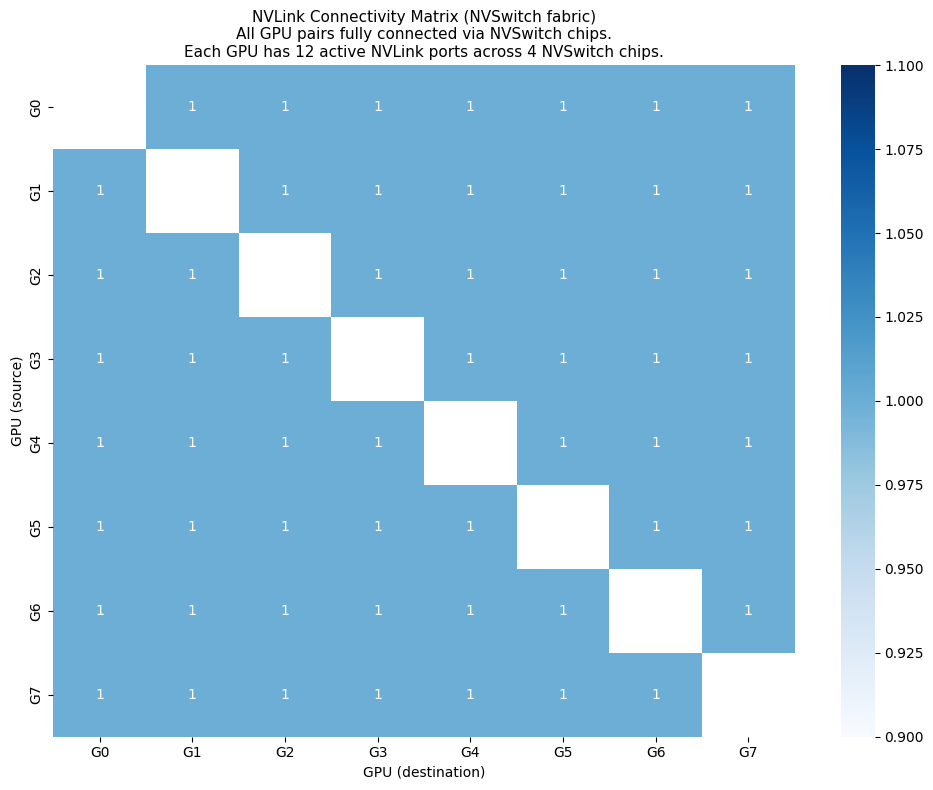

NVSwitch topology detected: all GPUs connected all-to-all via 4 NVSwitch chips.
Active NVLink ports per GPU: {0: 12, 1: 12, 2: 12, 3: 12, 4: 12, 5: 12, 6: 12, 7: 12}


In [5]:
# Visualize NVLink topology as a connectivity matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Detect whether NVLink remotes are GPUs or NVSwitches.
# On HGX/DGX nodes, GPUs connect to NVSwitch chips (not directly to each other).
sample_handle = handles[0]
remote_types = set()
for link in range(MAX_NVLINK_PORTS):
    try:
        state = pynvml.nvmlDeviceGetNvLinkState(sample_handle, link)
        if state == pynvml.NVML_FEATURE_ENABLED:
            rt = pynvml.nvmlDeviceGetNvLinkRemoteDeviceType(sample_handle, link)
            remote_types.add(rt)
    except pynvml.NVMLError:
        break

nvswitch_topology = (pynvml.NVML_NVLINK_DEVICE_TYPE_SWITCH in remote_types)

if nvswitch_topology:
    # NVSwitch fabric: all GPUs are fully connected all-to-all via NVSwitch chips.
    # The NVLink ports per GPU connect to NVSwitch chips, not directly to peer GPUs.
    active_ports = {
        i: sum(
            1 for link in range(MAX_NVLINK_PORTS)
            if pynvml.nvmlDeviceGetNvLinkState(handles[i], link) == pynvml.NVML_FEATURE_ENABLED
        )
        for i in range(gpu_count)
    }
    # All off-diagonal pairs are connected via NVSwitch
    adj = np.ones((gpu_count, gpu_count), dtype=int)
    np.fill_diagonal(adj, 0)
    title = (
        "NVLink Connectivity Matrix (NVSwitch fabric)\n"
        "All GPU pairs fully connected via NVSwitch chips.\n"
        f"Each GPU has {active_ports[0]} active NVLink ports across 4 NVSwitch chips."
    )
else:
    # Direct GPU-to-GPU NVLink (no NVSwitch)
    bus_to_gpu = {}
    for i, handle in enumerate(handles):
        pci = pynvml.nvmlDeviceGetPciInfo(handle)
        bus_to_gpu[pci.busId] = i
    adj = np.zeros((gpu_count, gpu_count), dtype=int)
    for gpu_i, links in nvlink_topology.items():
        for link_id, remote_bus in links.items():
            if remote_bus in bus_to_gpu:
                adj[gpu_i, bus_to_gpu[remote_bus]] += 1
    title = "NVLink Connectivity Matrix\n(cell value = number of NVLink ports connecting GPU i to GPU j)"

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(adj, ax=ax, cmap='Blues', annot=True, fmt='d',
            mask=(adj == 0),
            xticklabels=[f'G{i}' for i in range(gpu_count)],
            yticklabels=[f'G{i}' for i in range(gpu_count)])
ax.set_title(title, fontsize=11)
ax.set_xlabel('GPU (destination)')
ax.set_ylabel('GPU (source)')
plt.tight_layout()
plt.savefig('nvlink_topology.png', dpi=150, bbox_inches='tight')
plt.show()

if nvswitch_topology:
    print("NVSwitch topology detected: all GPUs connected all-to-all via 4 NVSwitch chips.")
    print(f"Active NVLink ports per GPU: {active_ports}")
else:
    print("\nNote: GPUs with 0 connections communicate via InfiniBand (inter-baseboard).")


---
## 3. Metric Collection

### What we're collecting and why

| Metric | Why it matters | Training signature | Inference signature |
|---|---|---|---|
| **Power (W)** | Hardest signal to fake. Measurable externally (utility meter). | Flat, sustained, high | Spiky, demand-following |
| **SM utilization (%)** | Fraction of streaming multiprocessors active | Relentlessly high | Bursty |
| **Memory used (GB)** | Training needs optimizer states + activations + gradients | Very high, stable | Lower, fluctuates with KV cache |
| **Temperature (°C)** | Tracks power closely | Sustained high | Variable |
| **PCIe TX/RX** | Host↔GPU data movement | Periodic (checkpoint writes, data loads) | Constant (token I/O) |
| **NVLink TX/RX** | **The smoking gun.** All-reduce syncs gradient data across all GPUs simultaneously | Massive periodic symmetric bursts | Sparse, asymmetric |

We're collecting an **idle baseline** first — no workload running. This gives us the floor to compare against.

In [6]:
def collect_snapshot(handles, t=None):
    """
    Collect one snapshot of all per-GPU metrics via NVML.
    Returns a list of dicts, one per GPU.
    """
    if t is None:
        t = time.time()

    records = []
    for i, handle in enumerate(handles):
        r = {'timestamp': t, 'gpu_id': i}

        # SM and memory copy utilization
        try:
            util = pynvml.nvmlDeviceGetUtilizationRates(handle)
            r['sm_util_pct'] = util.gpu
            r['mem_copy_util_pct'] = util.memory
        except Exception:
            r['sm_util_pct'] = r['mem_copy_util_pct'] = None

        # Memory
        try:
            mem = pynvml.nvmlDeviceGetMemoryInfo(handle)
            r['mem_used_gb'] = mem.used / 1e9
            r['mem_free_gb'] = mem.free / 1e9
            r['mem_total_gb'] = mem.total / 1e9
        except Exception:
            r['mem_used_gb'] = r['mem_free_gb'] = r['mem_total_gb'] = None

        # Power
        try:
            r['power_w'] = pynvml.nvmlDeviceGetPowerUsage(handle) / 1000.0  # mW → W
        except Exception:
            r['power_w'] = None

        # Temperature
        try:
            r['temp_c'] = pynvml.nvmlDeviceGetTemperature(handle, pynvml.NVML_TEMPERATURE_GPU)
        except Exception:
            r['temp_c'] = None

        # Clocks
        try:
            r['sm_clock_mhz'] = pynvml.nvmlDeviceGetClockInfo(handle, pynvml.NVML_CLOCK_SM)
            r['mem_clock_mhz'] = pynvml.nvmlDeviceGetClockInfo(handle, pynvml.NVML_CLOCK_MEM)
        except Exception:
            r['sm_clock_mhz'] = r['mem_clock_mhz'] = None

        # PCIe throughput
        try:
            r['pcie_tx_kb_s'] = pynvml.nvmlDeviceGetPcieThroughput(
                handle, pynvml.NVML_PCIE_UTIL_TX_BYTES)
            r['pcie_rx_kb_s'] = pynvml.nvmlDeviceGetPcieThroughput(
                handle, pynvml.NVML_PCIE_UTIL_RX_BYTES)
        except Exception:
            r['pcie_tx_kb_s'] = r['pcie_rx_kb_s'] = None

        # Fan speed (if present — NVL72 uses liquid cooling, may not have fans)
        try:
            r['fan_speed_pct'] = pynvml.nvmlDeviceGetFanSpeed(handle)
        except Exception:
            r['fan_speed_pct'] = None

        records.append(r)
    return records

In [7]:
from tqdm.notebook import tqdm

DURATION_SEC = 60
INTERVAL_SEC = 1.0

print(f"Collecting {DURATION_SEC}s of idle baseline at {INTERVAL_SEC}s intervals...")
print(f"({gpu_count} GPUs × {DURATION_SEC} samples = {gpu_count * DURATION_SEC} rows)\n")

all_records = []
start_time = time.time()
n_samples = int(DURATION_SEC / INTERVAL_SEC)

for _ in tqdm(range(n_samples)):
    loop_start = time.time()
    all_records.extend(collect_snapshot(handles))
    elapsed = time.time() - loop_start
    sleep_time = max(0, INTERVAL_SEC - elapsed)
    time.sleep(sleep_time)

df = pd.DataFrame(all_records)
df['elapsed_sec'] = df['timestamp'] - df['timestamp'].min()

print(f"\nCollected: {len(df)} rows × {len(df.columns)} columns")
print(f"Columns: {list(df.columns)}")

# Save raw data
df.to_csv('telemetry_baseline.csv', index=False)
print("\nSaved: telemetry_baseline.csv")

(8 GPUs × 60 samples = 480 rows)



  0%|          | 0/60 [00:00<?, ?it/s]


Collected: 480 rows × 15 columns
Columns: ['timestamp', 'gpu_id', 'sm_util_pct', 'mem_copy_util_pct', 'mem_used_gb', 'mem_free_gb', 'mem_total_gb', 'power_w', 'temp_c', 'sm_clock_mhz', 'mem_clock_mhz', 'pcie_tx_kb_s', 'pcie_rx_kb_s', 'fan_speed_pct', 'elapsed_sec']

Saved: telemetry_baseline.csv


In [8]:
# Summary statistics across all GPUs
print("=== Per-GPU Summary (mean ± std over collection window) ===\n")
summary_cols = ['sm_util_pct', 'mem_copy_util_pct', 'power_w', 'temp_c', 'mem_used_gb', 'sm_clock_mhz']
summary_cols = [c for c in summary_cols if c in df.columns]

agg = df.groupby('gpu_id')[summary_cols].agg(['mean', 'std', 'min', 'max'])
agg.columns = [f'{m}_{s}' for m, s in agg.columns]

# Clean display
for col in summary_cols:
    cols_to_show = [f'{col}_mean', f'{col}_std', f'{col}_min', f'{col}_max']
    cols_to_show = [c for c in cols_to_show if c in agg.columns]
    if cols_to_show:
        print(f"--- {col} ---")
        display(agg[cols_to_show].round(2))
        print()

=== Per-GPU Summary (mean ± std over collection window) ===

--- sm_util_pct ---


,sm_util_pct_mean,sm_util_pct_std,sm_util_pct_min,sm_util_pct_max
gpu_id,,,,
0,0.0,0.0,0,0
1,0.0,0.0,0,0
2,0.0,0.0,0,0
3,0.0,0.0,0,0
4,0.0,0.0,0,0
5,0.0,0.0,0,0
6,0.0,0.0,0,0
7,0.0,0.0,0,0



--- mem_copy_util_pct ---


,mem_copy_util_pct_mean,mem_copy_util_pct_std,mem_copy_util_pct_min,mem_copy_util_pct_max
gpu_id,,,,
0,0.0,0.0,0,0
1,0.0,0.0,0,0
2,0.0,0.0,0,0
3,0.0,0.0,0,0
4,0.0,0.0,0,0
5,0.0,0.0,0,0
6,0.0,0.0,0,0
7,0.0,0.0,0,0



--- power_w ---


...

,temp_c_mean,temp_c_std,temp_c_min,temp_c_max
gpu_id,,,,
0,36.00,0.00,36,36
1,36.00,0.00,36,36
2,34.75,0.44,34,35
3,36.00,0.00,36,36
4,36.00,0.00,36,36
5,36.00,0.00,36,36
6,36.00,0.00,36,36
7,34.00,0.00,34,34



--- mem_used_gb ---


,mem_used_gb_mean,mem_used_gb_std,mem_used_gb_min,mem_used_gb_max
gpu_id,,,,
0,0.8,0.0,0.8,0.8
1,0.8,0.0,0.8,0.8
2,0.8,0.0,0.8,0.8
3,0.8,0.0,0.8,0.8
4,0.8,0.0,0.8,0.8
5,0.8,0.0,0.8,0.8
6,0.8,0.0,0.8,0.8
7,0.8,0.0,0.8,0.8



--- sm_clock_mhz ---


,sm_clock_mhz_mean,sm_clock_mhz_std,sm_clock_mhz_min,sm_clock_mhz_max
gpu_id,,,,
0,210.0,0.0,210,210
1,210.0,0.0,210,210
2,210.0,0.0,210,210
3,210.0,0.0,210,210
4,210.0,0.0,210,210
5,210.0,0.0,210,210
6,210.0,0.0,210,210
7,210.0,0.0,210,210


---
## 4. Visualization Dashboard

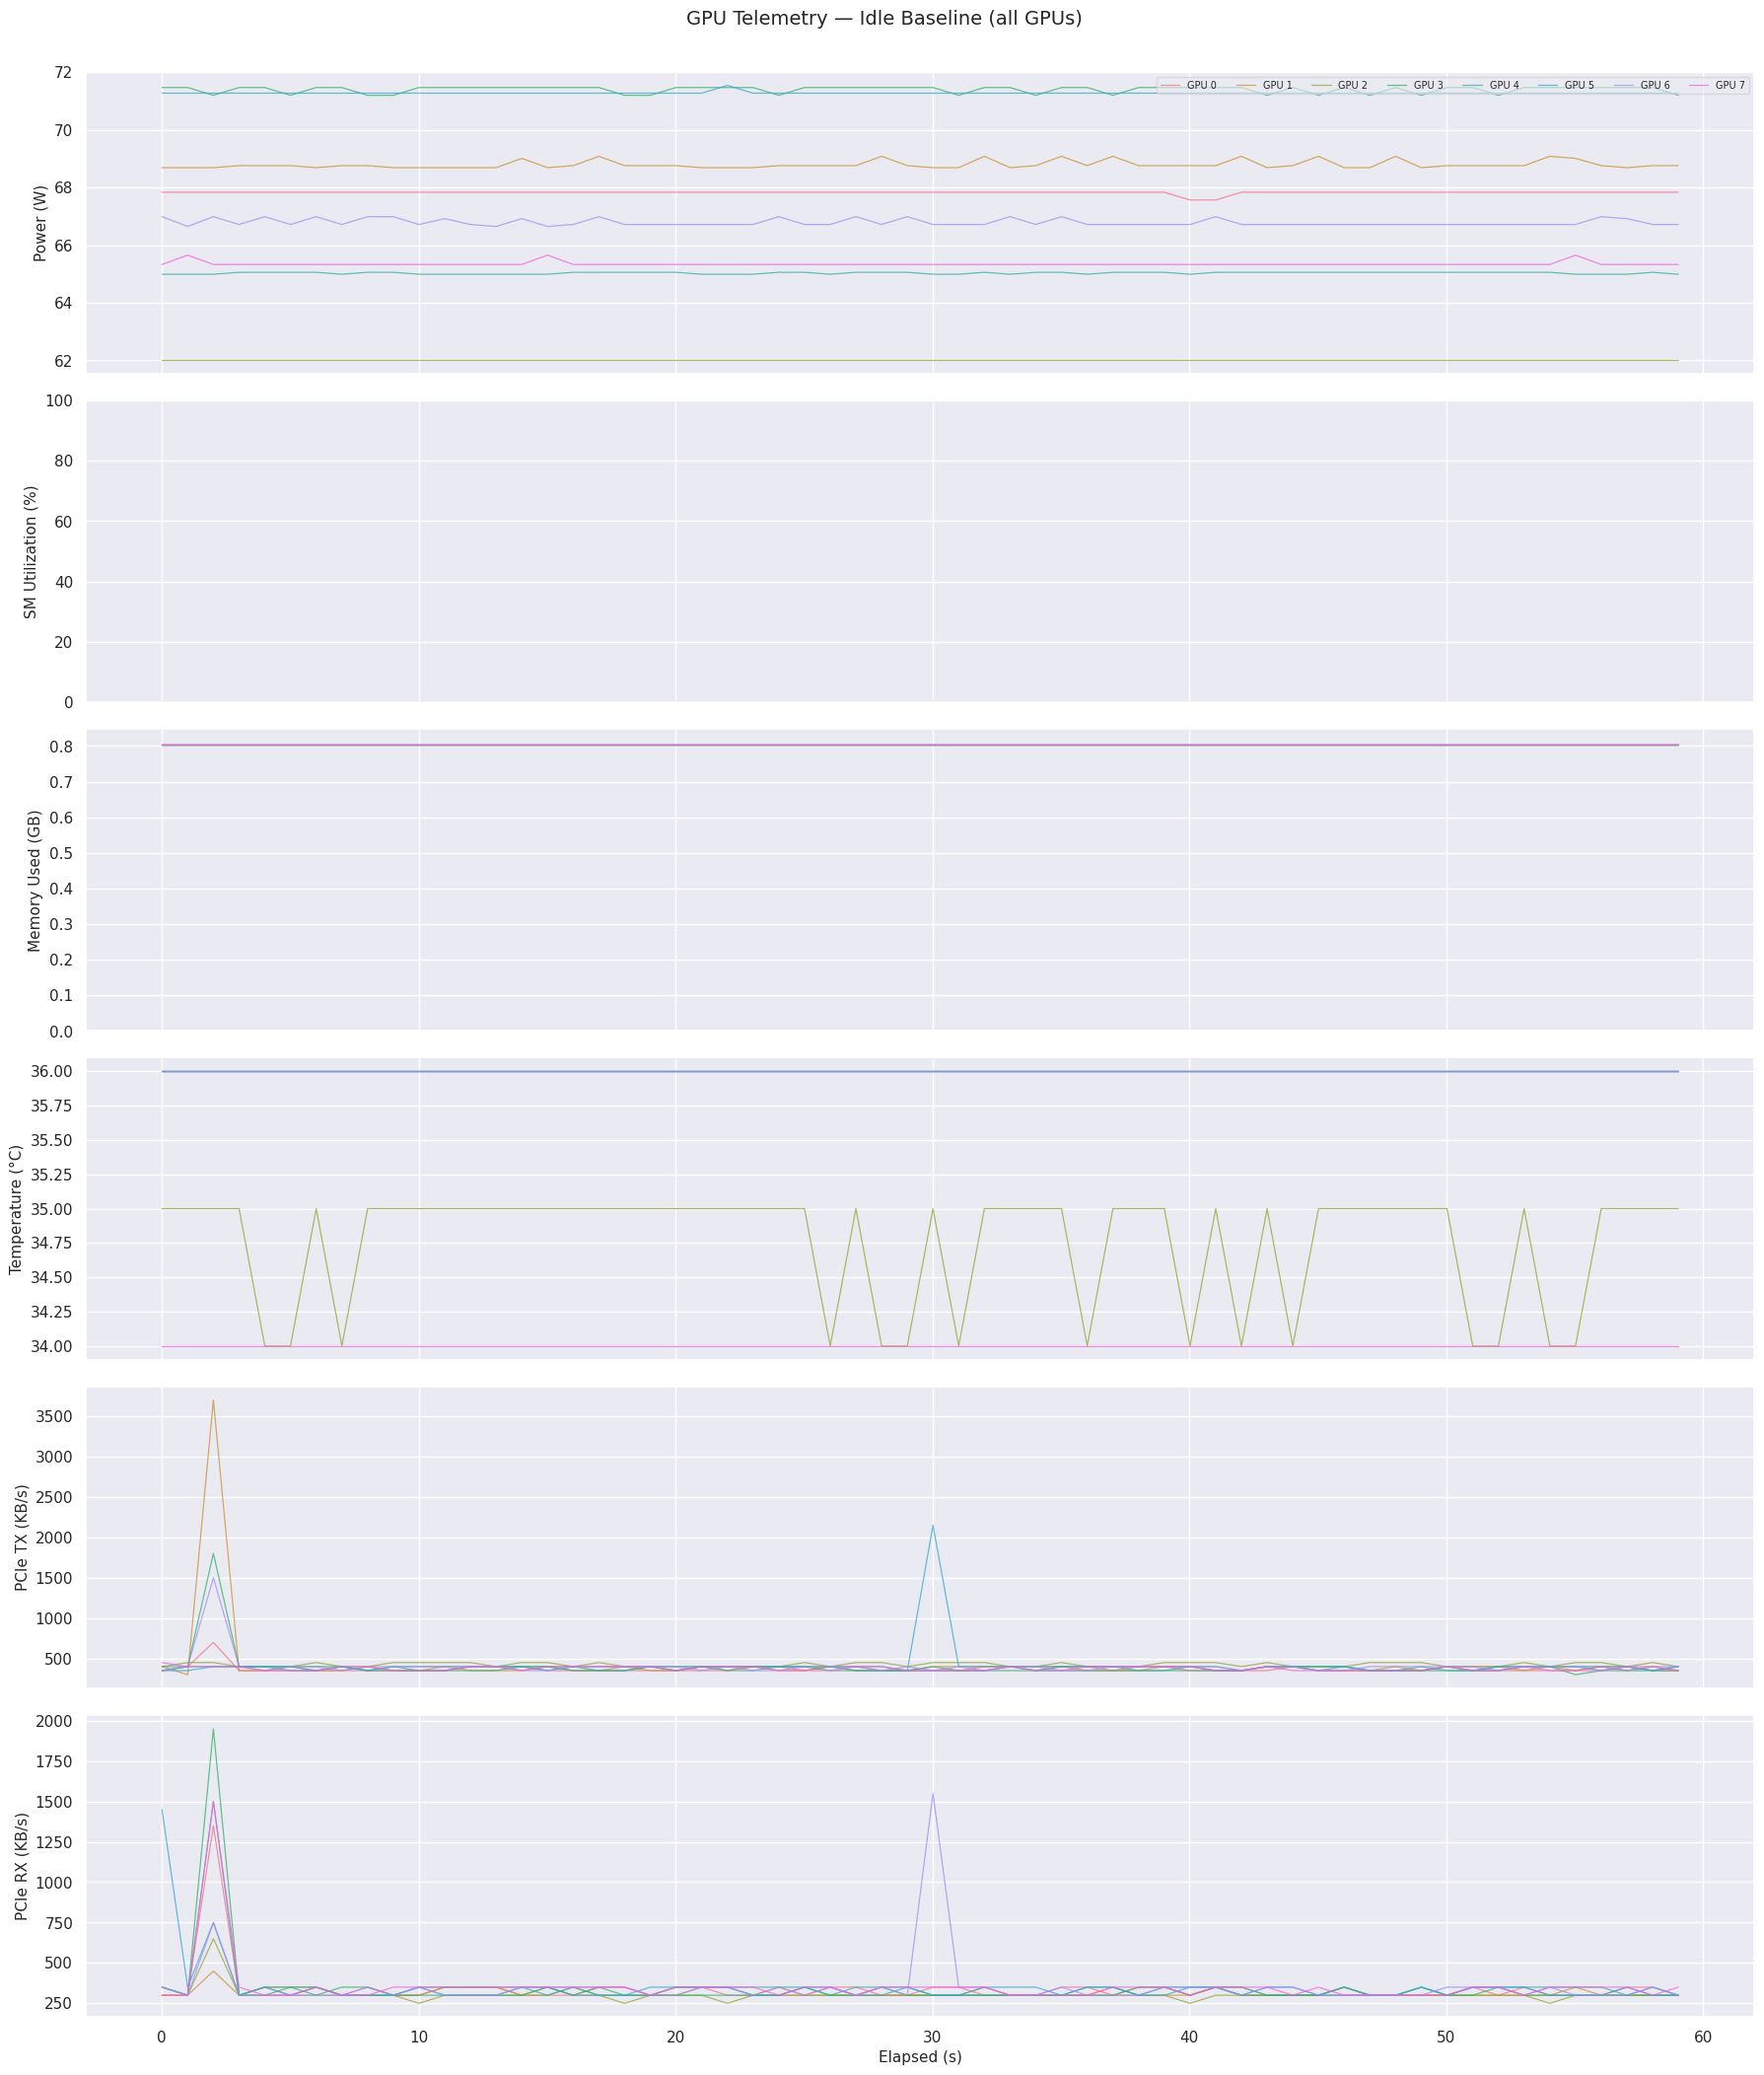

Saved: telemetry_dashboard.png


In [9]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

sns.set_theme(style='darkgrid', font_scale=1.0)
palette = sns.color_palette('husl', gpu_count)

# Metrics to plot: (column, ylabel, ylim or None)
panels = [
    ('power_w',          'Power (W)',            None),
    ('sm_util_pct',      'SM Utilization (%)',   (0, 100)),
    ('mem_used_gb',      'Memory Used (GB)',      (0, None)),
    ('temp_c',           'Temperature (°C)',      None),
    ('pcie_tx_kb_s',     'PCIe TX (KB/s)',        None),
    ('pcie_rx_kb_s',     'PCIe RX (KB/s)',        None),
]
panels = [(col, label, ylim) for col, label, ylim in panels if col in df.columns]

n_panels = len(panels)
fig, axes = plt.subplots(n_panels, 1, figsize=(18, 3.5 * n_panels), sharex=True)
if n_panels == 1:
    axes = [axes]

for ax, (col, ylabel, ylim) in zip(axes, panels):
    for i in range(gpu_count):
        gpu_df = df[df['gpu_id'] == i].sort_values('elapsed_sec')
        if gpu_df[col].notna().any():
            ax.plot(gpu_df['elapsed_sec'], gpu_df[col],
                    color=palette[i], alpha=0.75, linewidth=0.9, label=f'GPU {i}')
    ax.set_ylabel(ylabel, fontsize=11)
    if ylim:
        ax.set_ylim(ylim)

axes[-1].set_xlabel('Elapsed (s)', fontsize=11)

# Legend on first panel only
axes[0].legend(loc='upper right', ncol=min(gpu_count, 8), fontsize=7, framealpha=0.6)
fig.suptitle('GPU Telemetry — Idle Baseline (all GPUs)', fontsize=14, y=1.001)
plt.tight_layout()
plt.savefig('telemetry_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: telemetry_dashboard.png")

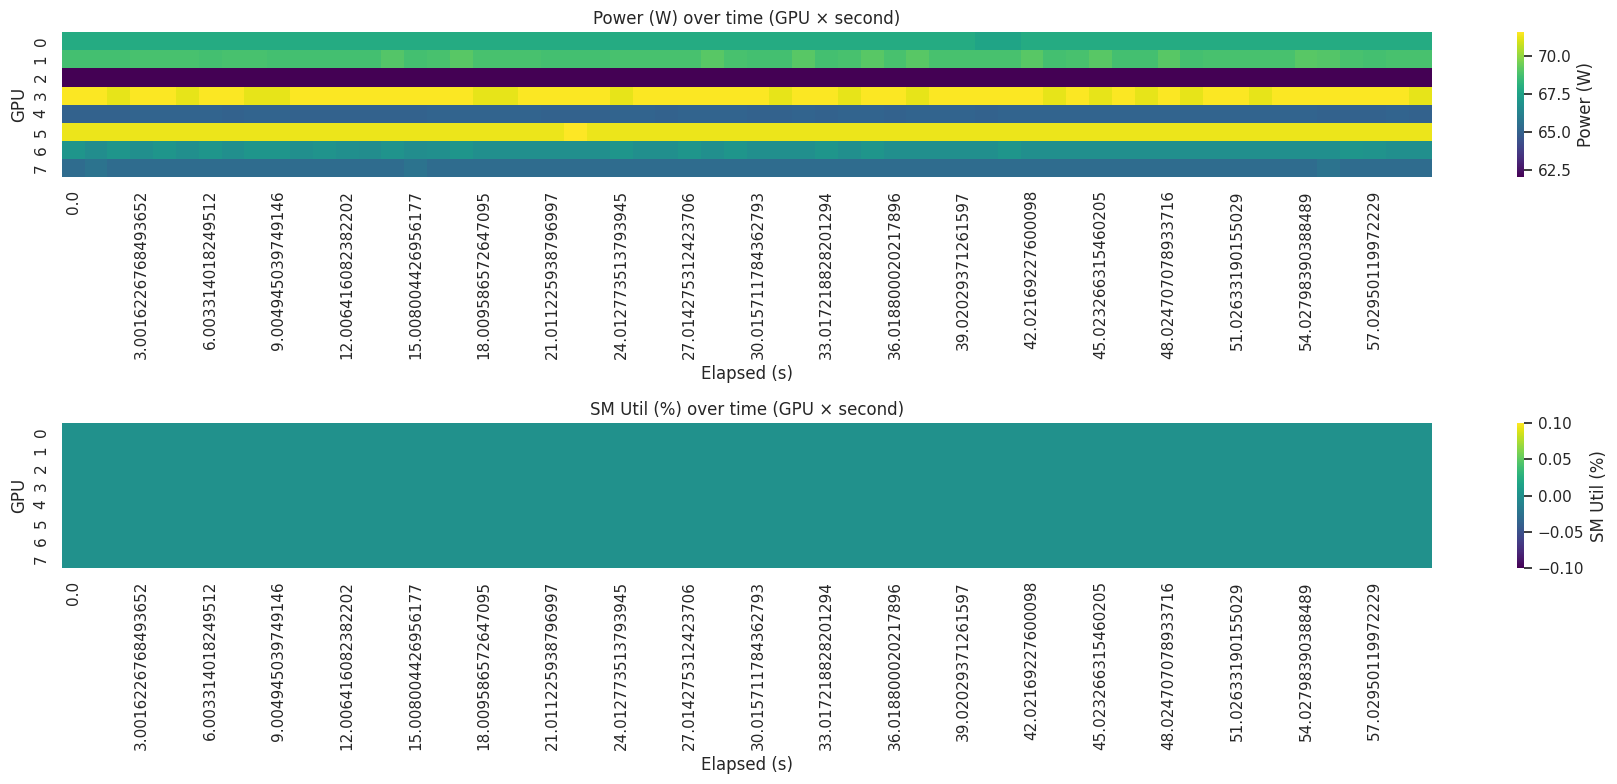

Saved: telemetry_heatmap.png


In [10]:
# Heatmap view: GPU × Time for power draw
# Easier to spot outlier GPUs (thermal throttle, stuck clock, etc.)

fig, axes = plt.subplots(2, 1, figsize=(18, 8))

for ax, (col, label) in zip(axes, [('power_w', 'Power (W)'), ('sm_util_pct', 'SM Util (%)')]):
    if col not in df.columns:
        continue
    pivot = df.pivot_table(index='gpu_id', columns='elapsed_sec', values=col)
    sns.heatmap(pivot, ax=ax, cmap='viridis', cbar_kws={'label': label},
                xticklabels=max(1, len(pivot.columns) // 20))
    ax.set_title(f'{label} over time (GPU × second)', fontsize=12)
    ax.set_xlabel('Elapsed (s)')
    ax.set_ylabel('GPU')

plt.tight_layout()
plt.savefig('telemetry_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: telemetry_heatmap.png")

---
## 5. DCGM Deep Dive: Per-Link NVLink Data

NVML (pynvml) exposes aggregate NVLink throughput per GPU. DCGM goes deeper: **per-link bytes transferred for each of the 12 NVLink ports on each A100**.

This is the data that would show the all-reduce heartbeat during training — a simultaneous burst across all links on all GPUs.

DCGM uses a daemon (`nv-hostengine`) that we query via the `dcgmi` CLI tool.

**Key field IDs for A100:**
- `203` = SM utilization
- `155` = Power (W)
- `150` = Temperature
- `100`, `101` = FB free/used memory (MiB)
- `409–420` = NVLink bandwidth per-link L0–L11 (cumulative byte counters)

In [11]:
import subprocess

def shell(cmd):
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    return result.stdout.strip(), result.stderr.strip(), result.returncode

# --- Check if DCGM is installed ---
stdout, _, rc = shell('which dcgmi')
if rc != 0:
    print("DCGM not found. Installing...")
    # Add NVIDIA repo key and install DCGM
    !wget -q https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64/cuda-keyring_1.1-1_all.deb
    !dpkg -i cuda-keyring_1.1-1_all.deb -y 2>/dev/null
    !apt-get update -q && apt-get install -y datacenter-gpu-manager 2>&1 | tail -5
else:
    print(f"DCGM found: {stdout}")

# --- Start nv-hostengine if not running ---
_, _, rc = shell('pgrep nv-hostengine')
if rc != 0:
    print("Starting nv-hostengine daemon...")
    shell('nv-hostengine')
    time.sleep(3)
    _, _, rc = shell('pgrep nv-hostengine')
    print("Started." if rc == 0 else "WARNING: Failed to start nv-hostengine")
else:
    print("nv-hostengine already running.")

# --- Verify DCGM can see GPUs ---
stdout, stderr, rc = shell('dcgmi discovery -l')
print("\nDCGM GPU Discovery:")
print(stdout or stderr)

DCGM found: /usr/bin/dcgmi
nv-hostengine already running.

DCGM GPU Discovery:
8 GPUs found.
+--------+----------------------------------------------------------------------+
| GPU ID | Device Information                                                   |
+--------+----------------------------------------------------------------------+
| 0      | Name: NVIDIA A100-SXM4-80GB                                          |
|        | PCI Bus ID: 00000000:07:00.0                                         |
|        | Device UUID: GPU-4be57cb5-46f7-32a6-c269-2bed6c114645                |
+--------+----------------------------------------------------------------------+
| 1      | Name: NVIDIA A100-SXM4-80GB                                          |
|        | PCI Bus ID: 00000000:08:00.0                                         |
|        | Device UUID: GPU-3a5dfa8f-306b-63ae-90fa-d34b0e322b64                |
+--------+----------------------------------------------------------------------+
| 2  

In [13]:
# Discover what NVLink fields are available on this node
stdout, _, _ = shell('dcgmi fieldids -l 2>/dev/null | grep -i nvlink')
print("Available NVLink fields in DCGM:")
print(stdout if stdout else "(none found — check DCGM version)")

print()

# Also check profiling fields (tensor core, DRAM active, etc.)
stdout, _, _ = shell('dcgmi fieldids -l 2>/dev/null | grep -i prof')
print("Available profiling fields:")
print(stdout if stdout else "(none found)")

Available NVLink fields in DCGM:
nvlink      Displays NvLink link statuses and error counts [dcgmi nvlink

Available profiling fields:
profile     Control and list DCGM profiling metrics


In [16]:
# Run dcgmi dmon to stream per-GPU + per-link NVLink metrics
# 
# Field IDs:
#   203 = DCGM_FI_DEV_GPU_UTIL (SM utilization %)
#   155 = DCGM_FI_DEV_POWER_USAGE (W)
#   150 = DCGM_FI_DEV_GPU_TEMP (°C)
#   100 = DCGM_FI_DEV_FB_FREE (MiB)
#   101 = DCGM_FI_DEV_FB_USED (MiB)
#   409–420 = DCGM_FI_DEV_NVLINK_BANDWIDTH_L0 to L11 (cumulative bytes per link)
#
# Note: 409-420 are CUMULATIVE counters. We'll diff consecutive readings for rates.

CORE_FIELDS = [203, 155, 150, 100, 101]
NVLINK_FIELDS = list(range(409, 421))  # L0 through L11
ALL_FIELDS = CORE_FIELDS + NVLINK_FIELDS
FIELDS_STR = ','.join(str(f) for f in ALL_FIELDS)

DCGM_DURATION_SEC = 60
DCGM_INTERVAL_MS = 1000

print(f"Running dcgmi dmon for {DCGM_DURATION_SEC}s...")
print(f"Fields: {FIELDS_STR}")

import threading

dmon_lines = []

def _reader(proc):
    for line in proc.stdout:
        dmon_lines.append(line)

proc = subprocess.Popen(
    ['dcgmi', 'dmon', '-e', FIELDS_STR, '-d', str(DCGM_INTERVAL_MS)],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE,
    text=True
)

reader_thread = threading.Thread(target=_reader, args=(proc,), daemon=True)
reader_thread.start()

for _ in tqdm(range(DCGM_DURATION_SEC)):
    time.sleep(1)

proc.terminate()
reader_thread.join(timeout=2)

print(f"\nCollected {len(dmon_lines)} raw lines")
print("\n--- First 25 lines (raw output) ---")
print(''.join(dmon_lines[:25]))


Running dcgmi dmon for 60s...
Fields: 203,155,150,100,101,409,410,411,412,413,414,415,416,417,418,419,420


  0%|          | 0/60 [00:00<?, ?it/s]


Collected 490 raw lines

--- First 25 lines (raw output) ---
#Entity   GPUTL             POWER             TMPTR        SMCLK        MMCLK        NFELT                       NDEL0                       NDEL1                       NDEL2                       NDEL3                       NDEL4                       NDEL5                       NDEL12                      NDEL13                      NDEL14                      NDELT                       NREL0                       
ID                           W                 C                                                                                                                                                                                                                                                                                                                                                                                     
GPU 7     0                 65.327            34           210          1593         0        

In [17]:
# Parse dcgmi dmon output into a DataFrame
#
# dcgmi dmon format (observed on this node):
#   Line 1: "#Entity   GPUTL   POWER   TMPTR   ..."  (field names)
#   Line 2: "#ID       W       C       ..."           (units — skip)
#   Data:   "GPU 7     0       65.327  34      ..."   (two-token entity prefix)
#   No blank-line separators between time steps on this version.

def parse_dmon(lines):
    col_names = None
    records = []
    step = 0
    seen_gpus_this_step = set()

    for line in lines:
        line = line.rstrip()
        if not line:
            continue

        if line.startswith('#'):
            stripped = line.lstrip('#').strip()
            parts = stripped.split()
            # First header line starts with "Entity" — those are the column names
            if parts and parts[0] == 'Entity':
                col_names = parts[1:]  # drop 'Entity', keep GPUTL/POWER/etc.
            # Second header line is units (W, C, ...) — skip it
            continue

        parts = line.split()
        if not parts:
            continue

        # Entity is "GPU X" (two tokens) or just an integer
        if parts[0] == 'GPU' and len(parts) > 1:
            try:
                gpu_id = int(parts[1])
                values = parts[2:]
            except ValueError:
                continue
        else:
            try:
                gpu_id = int(parts[0])
                values = parts[1:]
            except ValueError:
                continue

        # Detect new time step when we see a gpu_id we already recorded this step
        if gpu_id in seen_gpus_this_step:
            step += 1
            seen_gpus_this_step = set()
        seen_gpus_this_step.add(gpu_id)

        record = {'step': step, 'gpu_id': gpu_id}
        if col_names:
            for j, val in enumerate(values):
                col = col_names[j] if j < len(col_names) else f'field_{j}'
                try:
                    record[col] = float(val)
                except ValueError:
                    record[col] = None
        else:
            for j, val in enumerate(values):
                field_id = ALL_FIELDS[j] if j < len(ALL_FIELDS) else f'f{j}'
                try:
                    record[str(field_id)] = float(val)
                except ValueError:
                    record[str(field_id)] = None

        records.append(record)

    return pd.DataFrame(records) if records else pd.DataFrame()

dcgm_df = parse_dmon(dmon_lines)

if dcgm_df.empty:
    print("WARNING: Could not parse dmon output. Check the raw lines above.")
else:
    print(f"Parsed: {len(dcgm_df)} rows x {len(dcgm_df.columns)} columns")
    print(f"Steps: {dcgm_df['step'].nunique()}, GPUs: {dcgm_df['gpu_id'].nunique()}")
    print(f"Columns: {list(dcgm_df.columns)}")
    display(dcgm_df.head(10))


Parsed: 480 rows x 19 columns
Steps: 60, GPUs: 8
Columns: ['step', 'gpu_id', 'GPUTL', 'POWER', 'TMPTR', 'SMCLK', 'MMCLK', 'NFELT', 'NDEL0', 'NDEL1', 'NDEL2', 'NDEL3', 'NDEL4', 'NDEL5', 'NDEL12', 'NDEL13', 'NDEL14', 'NDELT', 'NREL0']


,step,gpu_id,GPUTL,POWER,TMPTR,SMCLK,MMCLK,NFELT,NDEL0,NDEL1,NDEL2,NDEL3,NDEL4,NDEL5,NDEL12,NDEL13,NDEL14,NDELT,NREL0
0,0,7,0.0,65.327,34.0,210.0,1593.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,6,0.0,66.986,36.0,210.0,1593.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,5,0.0,71.270,36.0,210.0,1593.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,4,0.0,64.989,36.0,210.0,1593.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,3,0.0,71.465,36.0,210.0,1593.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0,2,0.0,62.015,35.0,210.0,1593.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0,1,0.0,68.685,36.0,210.0,1593.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0,0,0.0,67.833,36.0,210.0,1593.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,1,7,0.0,65.327,34.0,210.0,1593.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,1,6,0.0,66.715,36.0,210.0,1593.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


NVLink columns found: ['NDEL0', 'NDEL1', 'NDEL2', 'NDEL3', 'NDEL4', 'NDEL5', 'NDEL12', 'NDEL13', 'NDEL14', 'NDELT', 'NREL0']


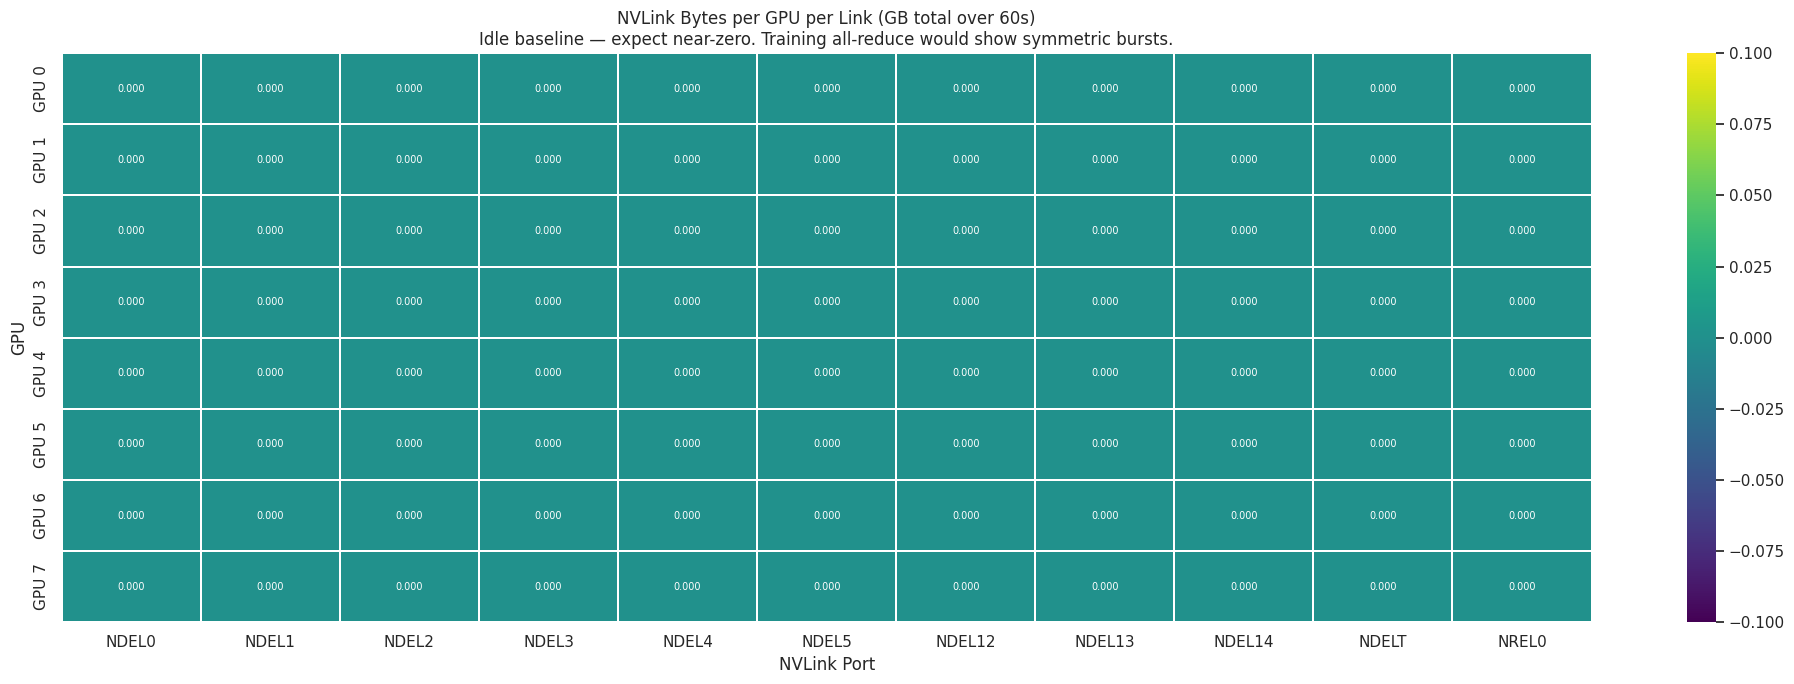

Saved: nvlink_per_link.png

Total NVLink traffic per GPU (GB):
gpu_id
0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
5    0.0
6    0.0
7    0.0
dtype: float64


In [18]:
# NVLink per-link heatmap
#
# The NVLink field values (409-420) are CUMULATIVE byte counters —
# they increase monotonically. We take last - first to get total bytes
# transferred over the collection window.
#
# On an idle node, these will be ~0 or very small (control-plane traffic only).
# During training with all-reduce, you'd see large values symmetrically
# distributed across all links of all GPUs — the "heartbeat" pattern.

if dcgm_df.empty:
    print("No DCGM data to visualize.")
else:
    # Find NVLink columns
    nvlink_cols = [
        col for col in dcgm_df.columns
        if ('NVLINK_BANDWIDTH' in col.upper()          # long DCGM names
            or col in [str(f) for f in NVLINK_FIELDS]  # raw field IDs
            or col.startswith('NDEL')                  # short names: NDEL0-NDEL14
            or col.startswith('NREL'))                 # short names: NREL0-NREL11
    ]
    print(f"NVLink columns found: {nvlink_cols}")

    if nvlink_cols:
        # Delta bytes per GPU per link (last - first)
        first = dcgm_df.groupby('gpu_id')[nvlink_cols].first()
        last  = dcgm_df.groupby('gpu_id')[nvlink_cols].last()
        delta_gb = (last - first).fillna(0) / 1e9  # bytes → GB

        # Clean up column names for display
        short_names = [
            c.replace('DCGM_FI_DEV_NVLINK_BANDWIDTH_', '').replace('DCGM_FI_DEV_NVLINK_', '')
            for c in nvlink_cols
        ]
        delta_gb.columns = short_names

        fig, ax = plt.subplots(figsize=(20, 7))
        sns.heatmap(
            delta_gb, ax=ax, cmap='viridis',
            xticklabels=short_names,
            yticklabels=[f'GPU {i}' for i in delta_gb.index],
            annot=(len(nvlink_cols) <= 12),  # annotate only if readable
            fmt='.3f',
            annot_kws={'size': 7},
            linewidths=0.3
        )
        ax.set_title(
            f'NVLink Bytes per GPU per Link (GB total over {DCGM_DURATION_SEC}s)\n'
            f'Idle baseline — expect near-zero. Training all-reduce would show symmetric bursts.',
            fontsize=12
        )
        ax.set_xlabel('NVLink Port')
        ax.set_ylabel('GPU')
        plt.tight_layout()
        plt.savefig('nvlink_per_link.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Saved: nvlink_per_link.png")

        # Print totals
        print("\nTotal NVLink traffic per GPU (GB):")
        print(delta_gb.sum(axis=1).round(4))
    else:
        print("No NVLink columns found in DCGM output.")
        print("This may mean fields 409-420 are not available on this DCGM version.")
        print("Try: dcgmi fieldids -l | grep -i nvlink   to find correct field IDs.")


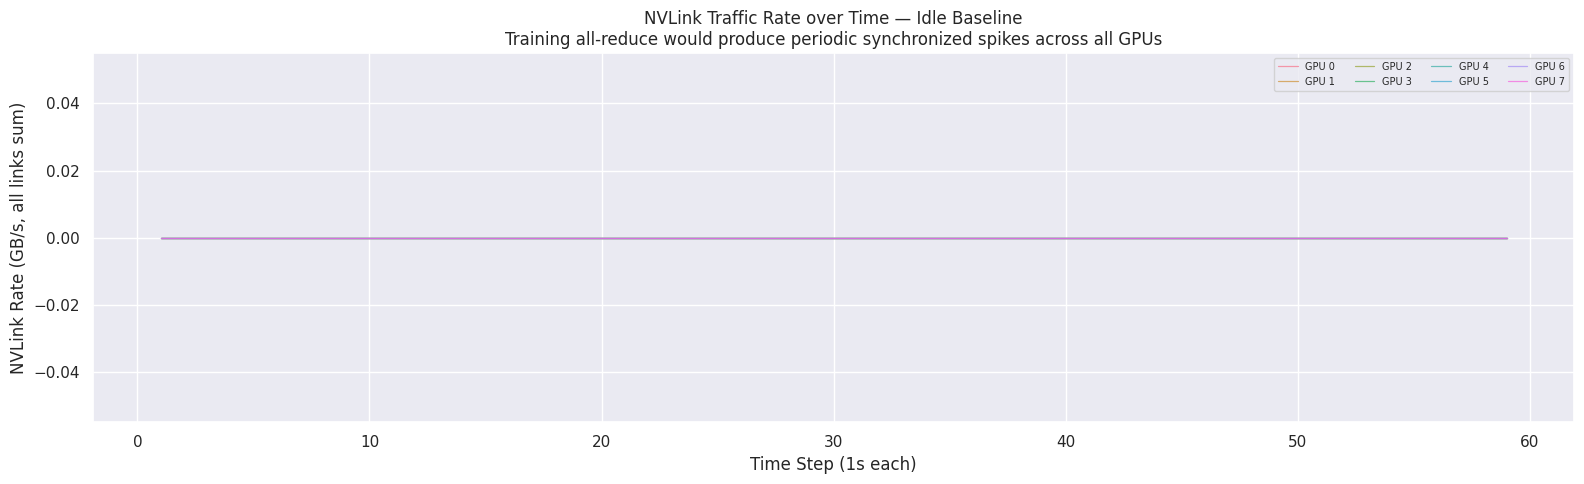

Saved: nvlink_rate_timeline.png


In [19]:
# NVLink traffic over time (per GPU, aggregate across all links)
# This shows the temporal pattern — the "heartbeat" would appear here during training

if not dcgm_df.empty and nvlink_cols:
    # Sum across all links per GPU per step
    dcgm_df['nvlink_total_gb'] = dcgm_df[nvlink_cols].sum(axis=1) / 1e9
    
    # Compute rate: diff over consecutive steps
    dcgm_df_sorted = dcgm_df.sort_values(['gpu_id', 'step'])
    dcgm_df_sorted['nvlink_rate_gb_s'] = dcgm_df_sorted.groupby('gpu_id')['nvlink_total_gb'].diff()

    fig, ax = plt.subplots(figsize=(16, 5))
    for i in range(gpu_count):
        gdf = dcgm_df_sorted[dcgm_df_sorted['gpu_id'] == i]
        ax.plot(gdf['step'], gdf['nvlink_rate_gb_s'],
                color=palette[i], alpha=0.7, linewidth=0.9, label=f'GPU {i}')

    ax.set_xlabel('Time Step (1s each)')
    ax.set_ylabel('NVLink Rate (GB/s, all links sum)')
    ax.set_title('NVLink Traffic Rate over Time — Idle Baseline\n'
                 'Training all-reduce would produce periodic synchronized spikes across all GPUs')
    ax.legend(ncol=4, fontsize=7, loc='upper right')
    plt.tight_layout()
    plt.savefig('nvlink_rate_timeline.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: nvlink_rate_timeline.png")

---
## 6. [SHELVED] Stress Test Workloads

Uncomment to run. Two workloads:
1. **Compute stress**: Matrix multiplications on all GPUs — spikes power + SM utilization, no NVLink
2. **NVLink stress**: Explicit all-reduce across GPUs — shows the heartbeat pattern in NVLink data

After running either, re-run the collection loop (Section 3) and re-run the visualizations to compare.

In [ ]:
## [SHELVED] Workload 1: Compute Stress (no NVLink)
## Hammers tensor cores on all GPUs simultaneously.
## Expected change from baseline: power ↑, SM util ↑, memory ↑, NVLink ~0

# import torch
# import threading
#
# def _gpu_matmul_loop(gpu_id, duration_sec, stop_event):
#     device = torch.device(f'cuda:{gpu_id}')
#     # Large FP16 matmul — hits tensor cores hard
#     a = torch.randn(8192, 8192, device=device, dtype=torch.float16)
#     b = torch.randn(8192, 8192, device=device, dtype=torch.float16)
#     while not stop_event.is_set():
#         c = torch.matmul(a, b)
#         torch.cuda.synchronize(device)
#
# def run_compute_stress(duration_sec=60):
#     print(f"Stressing {torch.cuda.device_count()} GPUs for {duration_sec}s...")
#     stop = threading.Event()
#     threads = [
#         threading.Thread(target=_gpu_matmul_loop, args=(i, duration_sec, stop))
#         for i in range(torch.cuda.device_count())
#     ]
#     for t in threads: t.start()
#     time.sleep(duration_sec)
#     stop.set()
#     for t in threads: t.join()
#     print("Done.")
#
# run_compute_stress(duration_sec=60)

In [ ]:
## [SHELVED] Workload 2: NVLink All-Reduce Stress
## Triggers the all-reduce communication pattern across all GPUs.
## This is what gradient synchronization looks like during training.
## Expected change: NVLink traffic spikes symmetrically across all GPUs.

# import torch
# import torch.distributed as dist
# import os
#
# # This needs to be run with torchrun, not directly in Jupyter.
# # Save the script below as allreduce_stress.py and run:
# #   torchrun --nproc_per_node=8 allreduce_stress.py
# # (or 16 for all 16 GPUs)
#
# ALLREDUCE_SCRIPT = '''
# import torch
# import torch.distributed as dist
# import time
#
# dist.init_process_group(backend='nccl')
# rank = dist.get_rank()
# device = torch.device(f'cuda:{rank}')
#
# # Simulate gradient tensor (large, like a real model's gradients)
# tensor = torch.randn(100_000_000, device=device, dtype=torch.float32)  # 400 MB
#
# print(f"Rank {rank}: starting all-reduce stress")
# start = time.time()
# n_iters = 0
# while time.time() - start < 60:
#     dist.all_reduce(tensor, op=dist.ReduceOp.SUM)
#     torch.cuda.synchronize(device)
#     n_iters += 1
#
# if rank == 0:
#     print(f"Completed {n_iters} all-reduce iterations in 60s")
# dist.destroy_process_group()
# '''
#
# with open('allreduce_stress.py', 'w') as f:
#     f.write(ALLREDUCE_SCRIPT)
# print("Wrote allreduce_stress.py")
# print("Run with: torchrun --nproc_per_node=8 allreduce_stress.py")